# Main Code to carry out blocking statistics and diagnostics on model data (CESM+others) and observations

### Specific Code to:
#### 1. Setup the analysis to be done and data to be ingested
#### 2. Climatology plots
#### 3. Jet latitude index
#### 4. 1D Frequency plots
#### 5. 2d Frequency plots
#### 6. PDF of blocking strengths
#### 7. Composite of plots conditioned on blocking strength
#### 8. PDF of blocking/baroclinic events length

In [8]:
import importlib
import blocking_utils as block_utils
import blocking_figs  as block_figs

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [10]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38383 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38383/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38383/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.115:40663,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/38383/status,Total threads: 0
Started: Just now,Total memory: 0 B



# TOP LEVEL OPTIONS


In [24]:
ens_names   = ['ERA5', 'MERRA', 'CESM1', 'CESM2',
               'b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.271',
               'b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.276']
ens_mem_num = [1, 1, 20, 20, 1, 1]
ens_ystart  = ['1979'] * len(ens_names)
ens_yend    = ['2005'] * len(ens_names)

block_season   = 'DJF'
cam_var        = 'Z500'
block_diag_set = ['1D', '2D']    # which diagnostics to compute


# MAIN ROUTINES


In [25]:
importlib.reload(block_utils) # Required because I am constantly editing utility routines.

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

 
++ Large ensemble =  CESM1 :  20  out of  42  total (first/last) ++
b.e11.B20TRC5CNBDRD.f09_g16.001
b.e11.B20TRC5CNBDRD.f09_g16.020
 
++ Large ensemble =  CESM2 :  20  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1231.010


# Grab daily datasets needed for each 'ensemble'

In [26]:
ensemble_ds = block_utils.dataset_get(block_meta, cam_var, block_season)

dataset_get: season=DJF
  ERA5: 1 member(s)  1979–2005
  MERRA: 1 member(s)  1979–2005
  CESM1: 20 member(s)  1979–2005
  CESM2: 20 member(s)  1979–2005
  CESM3-271: 1 member(s)  1979–2005
  CESM3-276: 1 member(s)  1979–2005
dataset_get: done in 67.9s



#  Calculate/Read/Write blocking frequency: 1D

In [33]:
ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '1D', file_opts = 'w')

  block_z500_freq: 1D blocking for ERA5
  Writing block_1D_ERA5_nens.1_1979-2005_DJF.nc
    ERA5: blocking 1.97–22.94%  (1.3s)
  block_z500_freq: 1D blocking for MERRA
  Writing block_1D_MERRA_nens.1_1979-2005_DJF.nc
    MERRA: blocking 1.56–22.04%  (3.1s)
  block_z500_freq: 1D blocking for CESM1
  Writing block_1D_CESM1_nens.20_1979-2005_DJF.nc
    CESM1: blocking 1.40–20.58%  (8.8s)
  block_z500_freq: 1D blocking for CESM2
  Writing block_1D_CESM2_nens.20_1979-2005_DJF.nc
    CESM2: blocking 1.44–19.92%  (10.8s)
  block_z500_freq: 1D blocking for CESM3-271
  Writing block_1D_CESM3-271_nens.1_1979-2005_DJF.nc
    CESM3-271: blocking 1.48–15.68%  (1.5s)
  block_z500_freq: 1D blocking for CESM3-276
  Writing block_1D_CESM3-276_nens.1_1979-2005_DJF.nc
    CESM3-276: blocking 1.73–22.26%  (5.5s)



# Calculate/Read/Write blocking frequency: 2D


In [34]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '2D', file_opts = 'w')

  block_z500_freq: 2D blocking for ERA5
  Writing block_2D_ERA5_nens.1_1979-2005_DJF.nc
    ERA5: blocking 0.00–28.35%  (1.3s)
  block_z500_freq: 2D blocking for MERRA
  Writing block_2D_MERRA_nens.1_1979-2005_DJF.nc
    MERRA: blocking 0.00–84.04%  (2.6s)
  block_z500_freq: 2D blocking for CESM1
  Writing block_2D_CESM1_nens.20_1979-2005_DJF.nc
    CESM1: blocking 0.00–58.52%  (8.5s)
  block_z500_freq: 2D blocking for CESM2
  Writing block_2D_CESM2_nens.20_1979-2005_DJF.nc
    CESM2: blocking 0.00–23.42%  (9.8s)
  block_z500_freq: 2D blocking for CESM3-271
  Writing block_2D_CESM3-271_nens.1_1979-2005_DJF.nc
    CESM3-271: blocking 0.00–82.96%  (1.3s)
  block_z500_freq: 2D blocking for CESM3-276
  Writing block_2D_CESM3-276_nens.1_1979-2005_DJF.nc
    CESM3-276: blocking 0.00–78.48%  (1.8s)



# Plot 1D blocking: Shade = 1,2 +/- std (or min to max range)


  Saved: /glade/u/home/rneale/python/python-figs/block_1d_freq_ERA5_MERRA_CESM1_CESM2_CESM3-271_CESM3-276_1979-2005_DJF.png
block_plot_1d: done in 0.3s


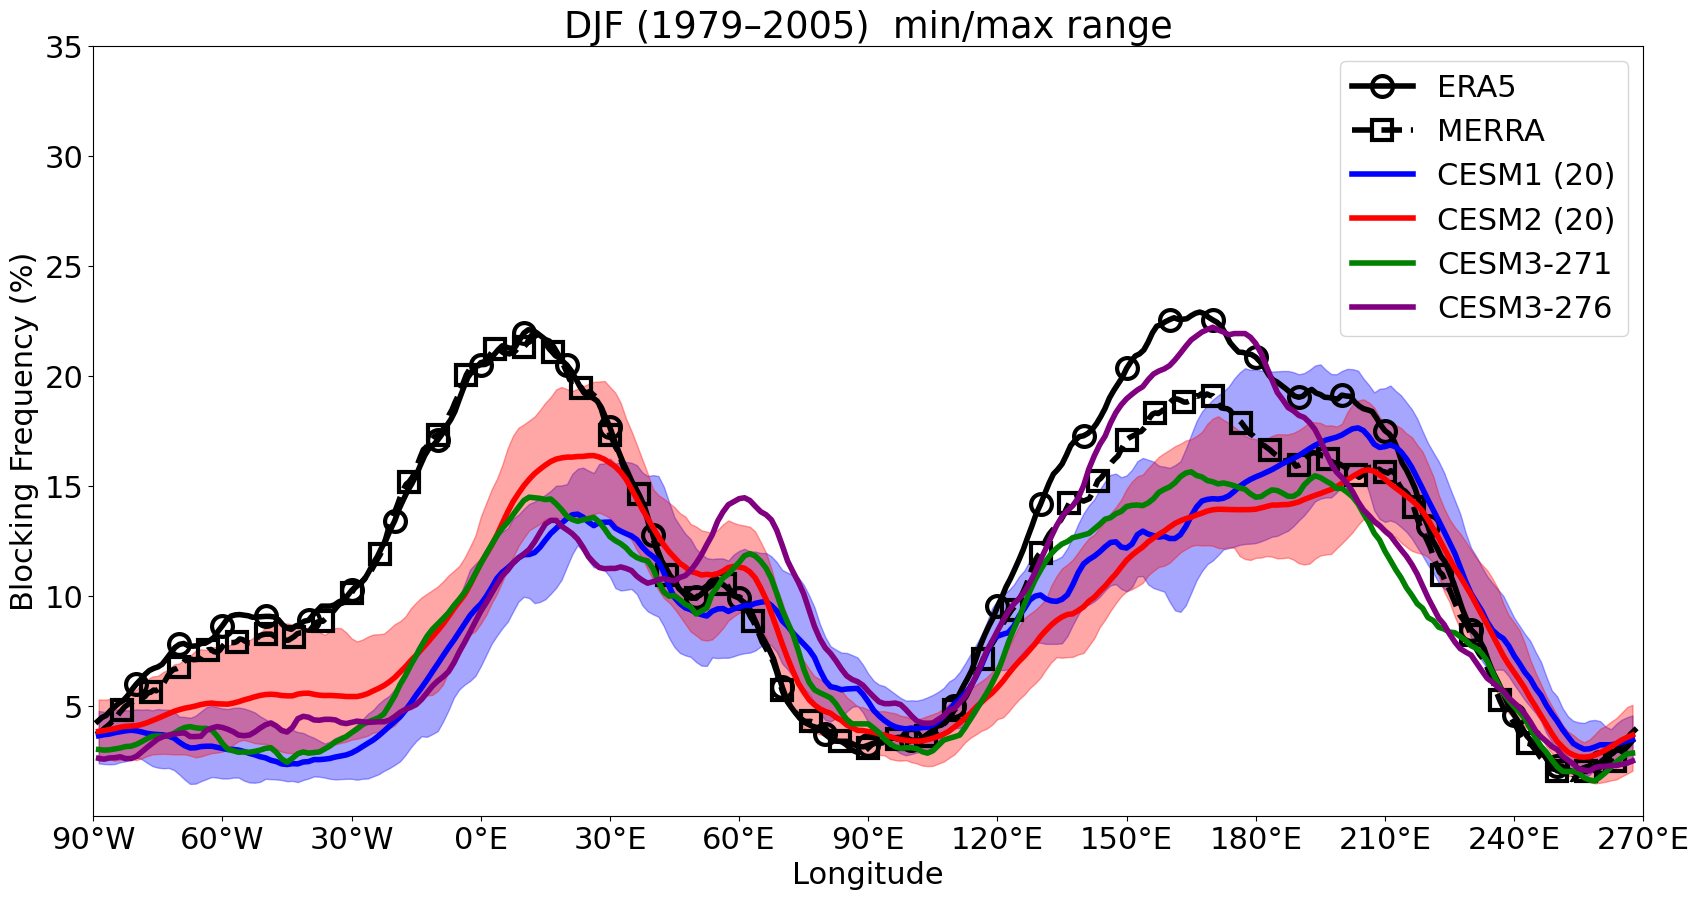

In [35]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True)


# Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


  Saved: /glade/u/home/rneale/python/python-figs/block_2d_freq_ERA5_MERRA_CESM1_CESM2_CESM3-271_CESM3-276_1979-2005_DJF.png


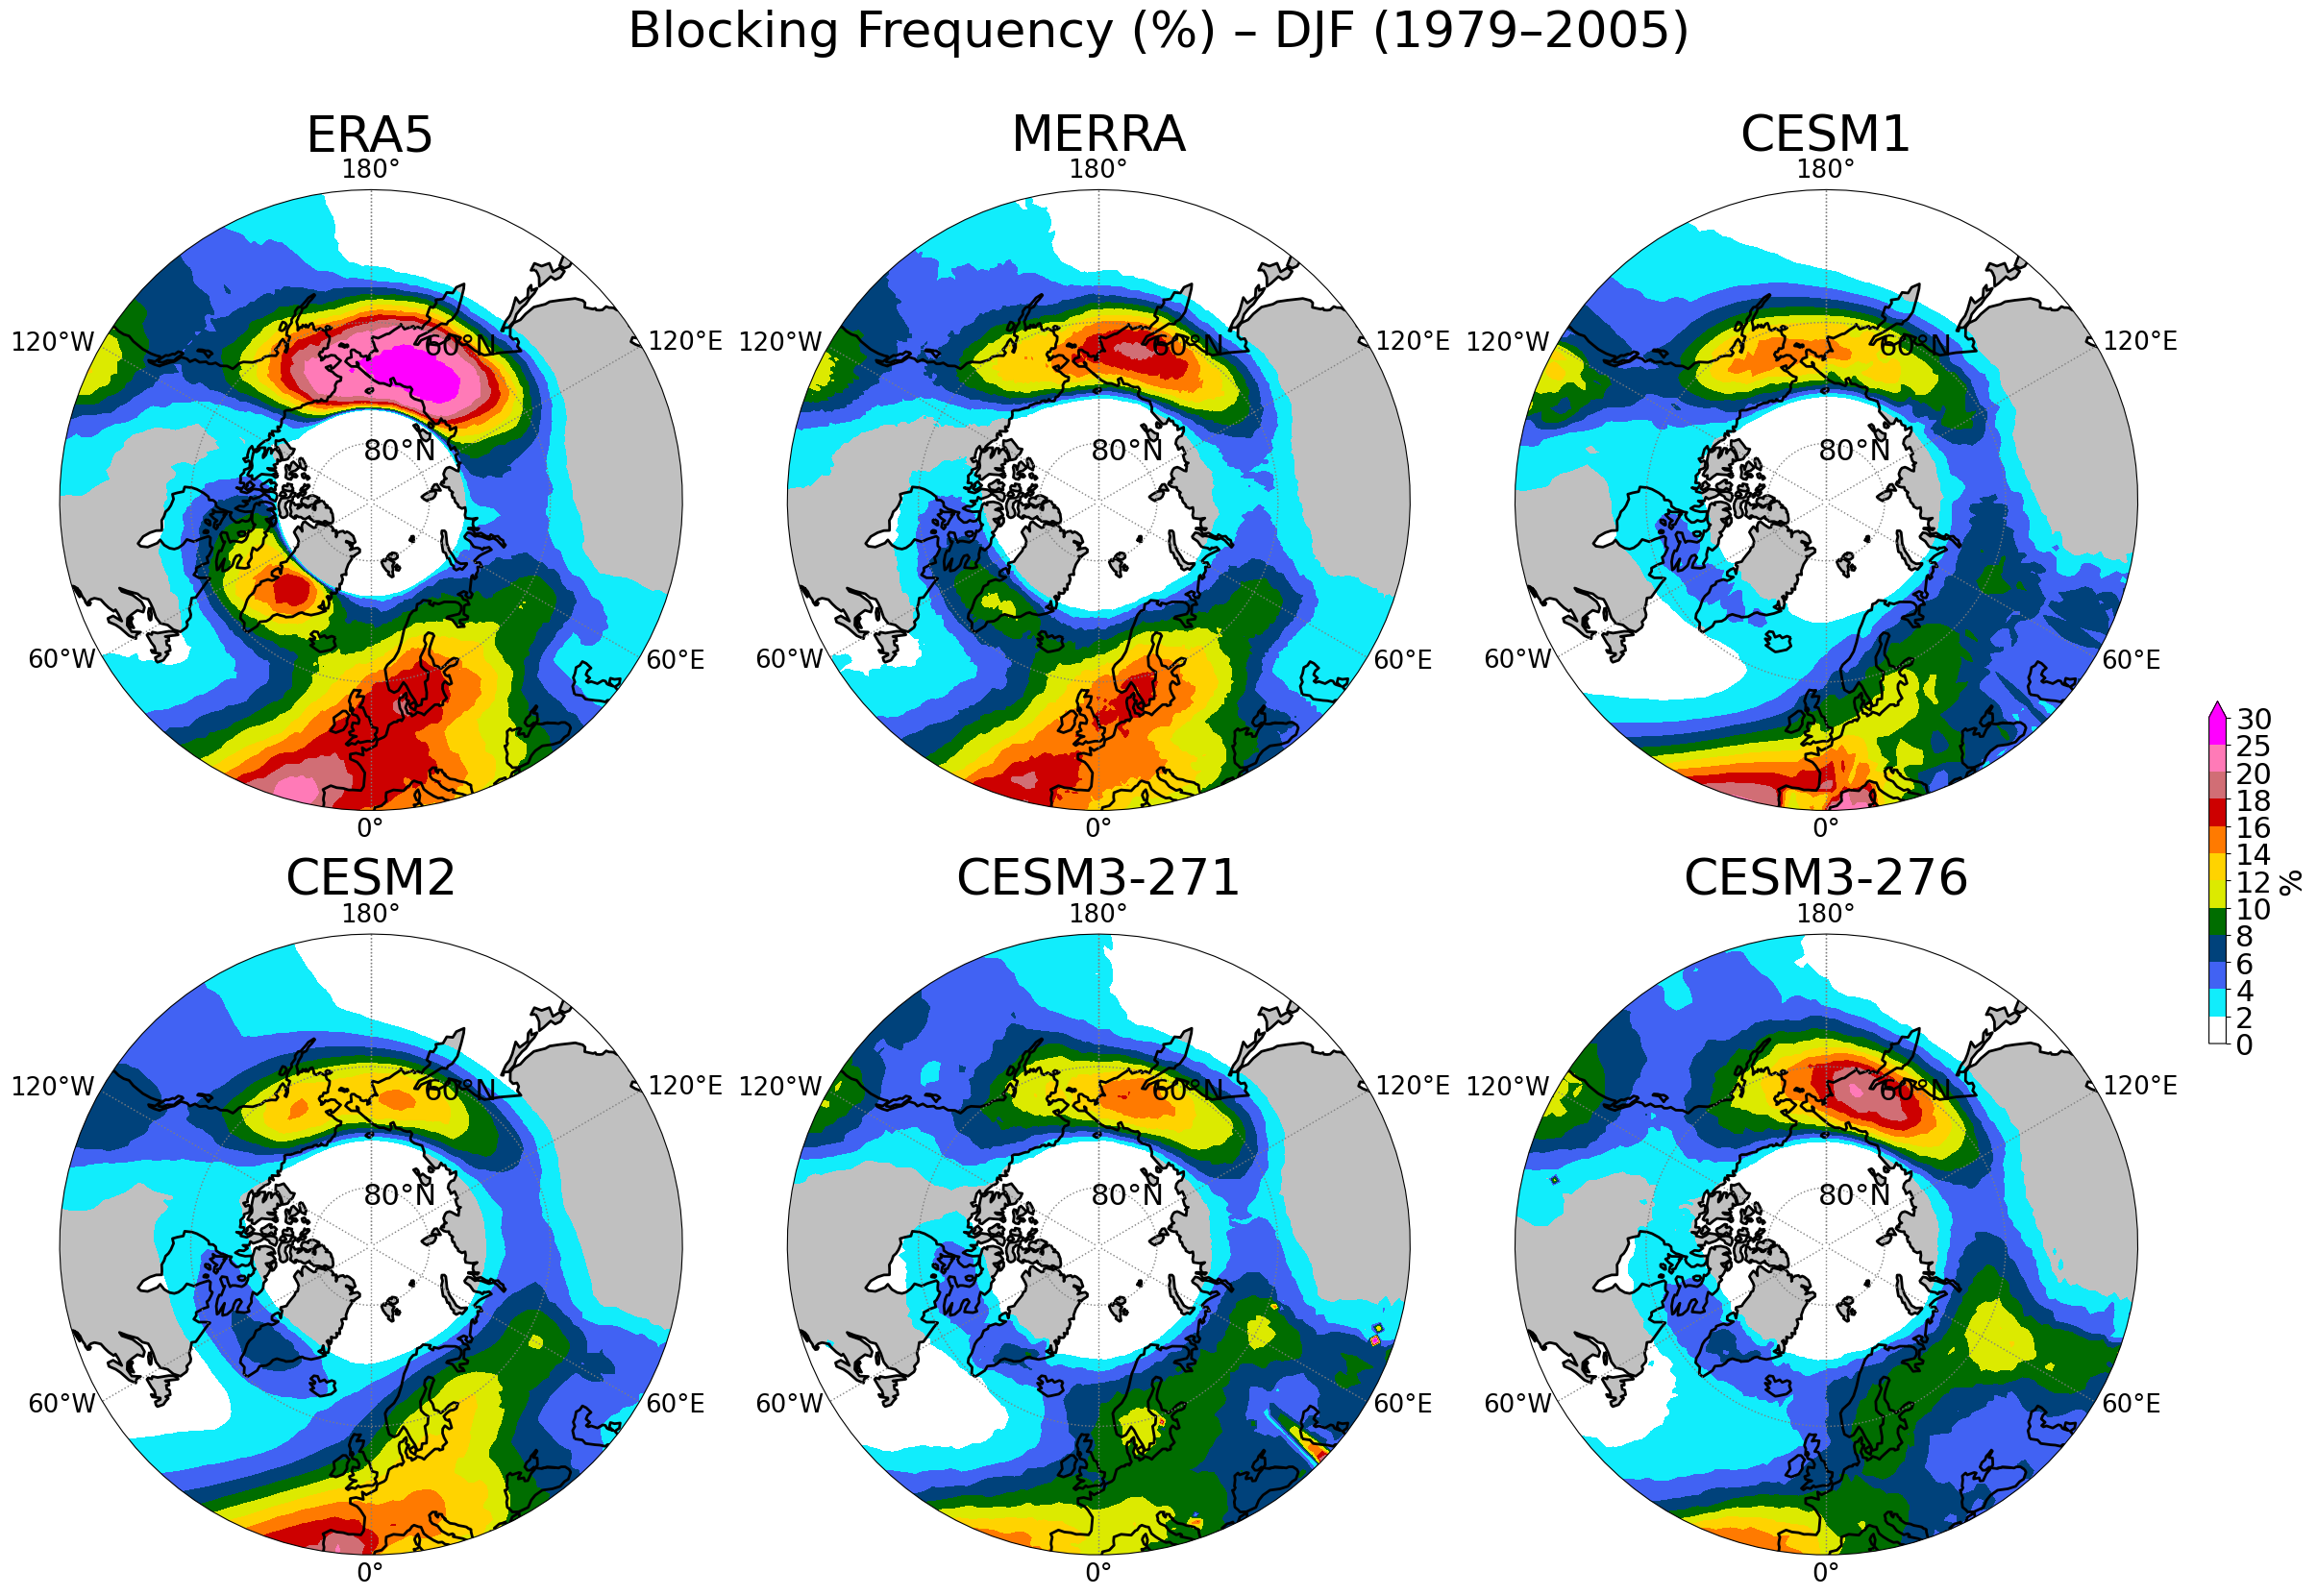

In [30]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,ens_plot='av')


# Plot 1d regional blocking PDFs (European, Pacific and Greenland)


  Saved: /glade/u/home/rneale/python/python-figs/block_1d_freq_ERA5_MERRA_CESM1_CESM2_CESM3-271_CESM3-276_1979-2005_DJF.png
block_plot_1d: done in 1.4s


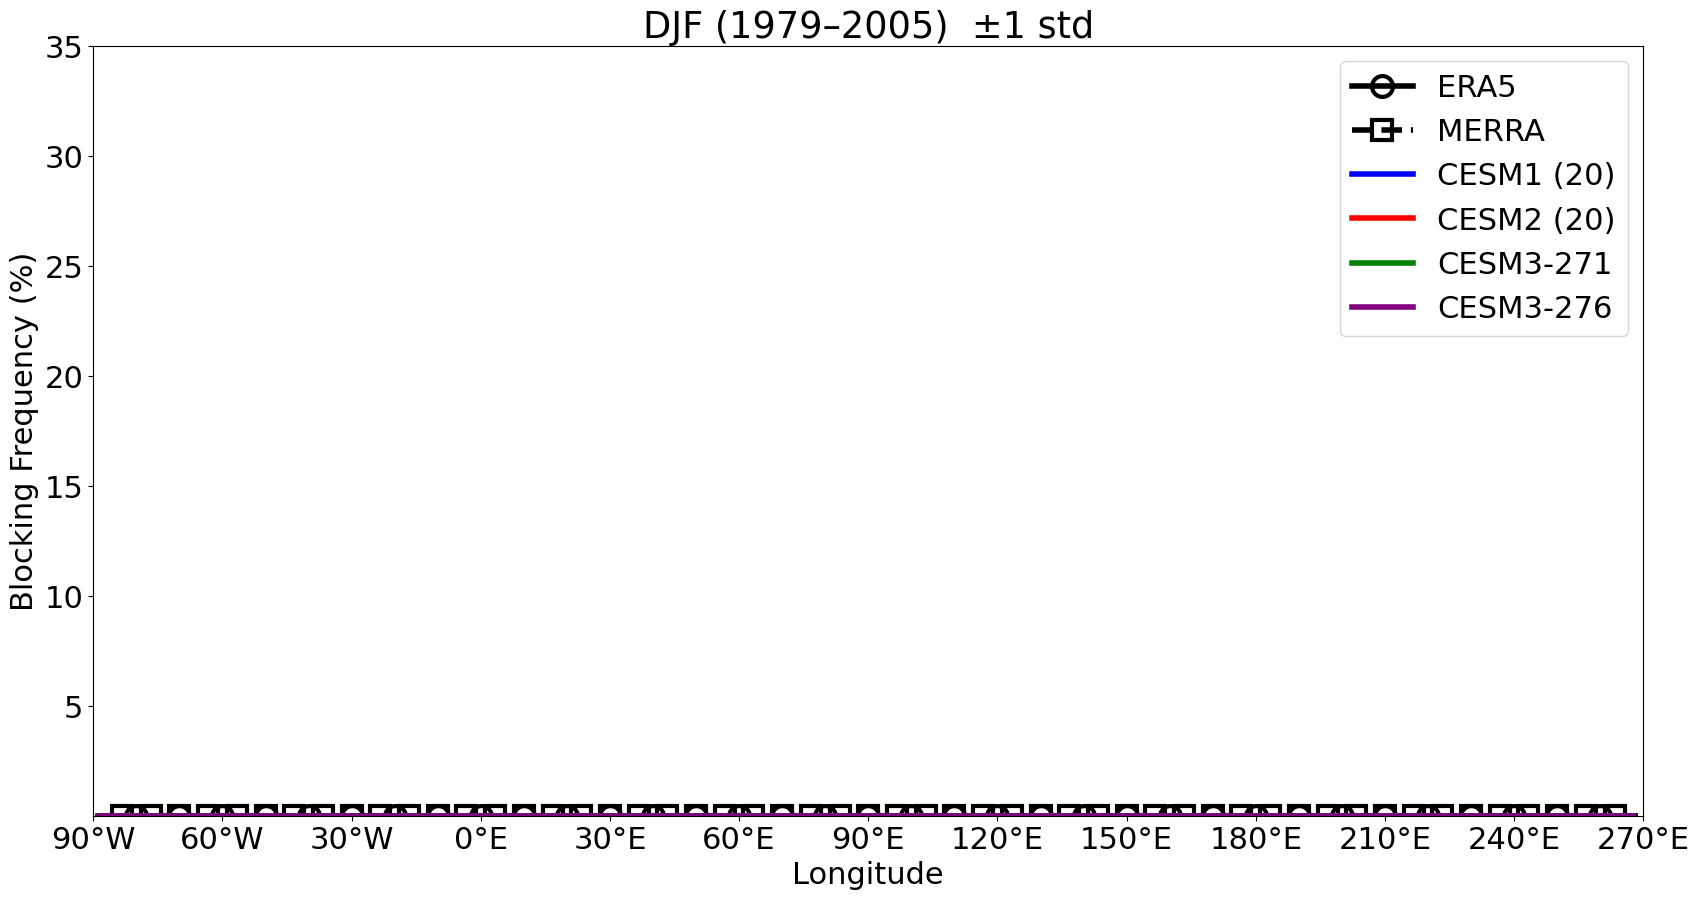

In [31]:
block_figs.block_plot_1d(block_meta, ensemble_block_1d, block_season,
                         pshade='1', fig_out=True)

In [22]:
#bstats = atmos_block.stats
#bclimo = atmos_block.climo
#bjet_lat = atmos_block.get_lat
#bfreq_1d = atmos_block.bfreq_1d
#bfreq_2d = atmos_block.bfreq_2d
#bpdf_1d = atmos_block.bfreq_2d
#bcomp_lag = atmos_block.bfreq_lag
#bday_len = atmos_block.bday_len